# HW3: Model Predictive Control
# Part 1: Planar drone MPC and obstacle avoidance using SQP
Ting-Wei Hsu (twhsu3)

In [246]:
import numpy as np
from qpsolvers import solve_problem, Problem
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown
import sympy as sp

# Suppress the display of very small numbers
np.set_printoptions(suppress=True)


## Dynamical System

Consider a planar drone with the equations of motion
$$
\begin{aligned}
\dot{p}_x &= v_x \\
\dot{p}_z &= v_z \\
\dot{\theta} &= \omega \\
m\dot{v}_x &= -(T_1 + T_2)\sin\theta \\
m\dot{v}_z &= (T_1 + T_2)\cos\theta - mg \\
J_y \dot{\omega} &= r(T_1 - T_2)
\end{aligned}
$$

where $m = 0.45$ is the mass; 
$r = 0.14$ is the spar length;
$J_y = 0.09$ is the moment of inertia about the $y$ (out-of-plane) axis;
$g = 9.81$ is the acceleration of gravity;
$step_z$ and $p_z$ are the components of position;
$\theta$ is the orientation;
$v_x$ and $v_z$ are the components of linear velocity;
$\omega$ is the angular velocity;
$T_1$ and $T_2$ are the forces produced by each rotor.

We define the state and input as
$$
x = [p_z,\; p_z,\; \theta,\; v_x,\; v_z,\; \omega]^\top,
 \qquad
u = [T_1,\; T_2]^\top
$$
and the dynamicas as 
$$
\dot{x} = f(x,u)
$$

In [247]:
m = 0.45
r = 0.14
Jy = 0.09
grav = 9.81
dt = 0.04
N = 25
sim_time = 5.0

x_dim = 6
u_dim = 2

def dynamics(x, u):
    px, pz, theta, vx, vz, omega = x
    T1, T2 = u
    return np.array([
        vx,
        vz,
        omega,
        -(T1 + T2) / m * np.sin(theta),
        (T1 + T2) / m * np.cos(theta) - grav,
        r * (T1 - T2) / Jy,
    ])


def Jacobian_dynamics(x, u):
    _, _, theta, _, _, _ = x
    T1, T2 = u

    A = np.zeros((x_dim, x_dim))
    A[0, 3] = 1.0
    A[1, 4] = 1.0
    A[2, 5] = 1.0
    A[3, 2] = -(T1 + T2) / m * np.cos(theta)
    A[4, 2] = -(T1 + T2) / m * np.sin(theta)

    B = np.zeros((x_dim, u_dim))
    B[3, :] = -(1.0 / m) * np.sin(theta)
    B[4, :] =  (1.0 / m) * np.cos(theta)
    B[5, 0] =  r / Jy
    B[5, 1] = -r / Jy
    return A, B


## Problem Formulation
The trajectory optimization problem with obstacle avoidance is formulated as the following optimal control problem:
$$
\begin{align}
\min_{\substack{x_0,\cdots x_N \\ u_0,\cdots u_{N-1}}}& \sum_{k=0}^{N-1} \frac{1}{2}(x_k - x_{\mathrm{ref},k})^\top Q (x_k - x_{\mathrm{ref},k}) + \frac{1}{2}(u_k - u_{\mathrm{ref},k})^\top R (u_k - u_{\mathrm{ref},k}) + \frac{1}{2}(x_N - x_{\mathrm{goal}})^\top Q_F (x_N - x_{\mathrm{goal}})\\

\text{s.t.} & \quad x_0 = x_{\mathrm{start}} \\
& \quad x_{k+1} - x_k - f(x_k, u_k) \Delta t = 0 \quad \forall k = 0,1,\cdots N-1 \\
& \quad (2r)^2 - (p_{x,k} - p_{\mathrm{obs},x})^2 - (p_{z,k} - p_{\mathrm{obs},z})^2 \leq 0

\end{align}
$$
where $J$ denotes the cost function, the decision variables are
- $x_0, \dots, x_N$ (with $x_0 = x_{\mathrm{start}}$)
- $u_0, \dots, u_{N-1}$

the dynamics constraint is encoded by the equality constraint in (3), and the obstacle avoidance constraint is encoded by the inequality constraint in (4).

In this homework, we consider 
- $N = 25$
- $\Delta t = 0.04$
- $x_{\mathrm{start}} = [0,0,0,0,0,0]^\top$ 
- $x_{\mathrm{goal}} = [3,0,0,0,0,0]^\top$
- $x_{\mathrm{ref},k} = x_{\mathrm{goal}} \quad \forall k=0,1,\cdots N$
- $u_{\mathrm{ref},k} = [mg/2, mg/2]^\top \quad \forall k=0,1,\cdots N$

The position of the obstacle $(p_{\mathrm{obs},x}, p_{\mathrm{obs},z})$ will be determined later.


For simplicity of notation, we will rewrite the optimal control problem using the following notation

$$
\begin{align*}
& \min_{\mathrm{z}} J(\mathrm{z})\\

\text{s.t.} &\quad g(\mathrm{z}) = 0 \\
&\quad h(\mathrm{z}) \leq 0,
\end{align*}
$$
where $\mathrm{z}=[x_0, \dots, x_N, u_0, \dots, u_{N-1}]^\top$ denote the decisiton variables, $g(\mathrm{z})$ denotes the equality constraint, and $h(\mathrm{z})$ denotes the inequality constraint.

Define the **Lagrangian function**

$$ L(\mathrm{z},\lambda, \nu) = J(\mathrm{z}) + \lambda^\top g(\mathrm{z}) + \nu^\top h(\mathrm{z})$$

and compute both its gradient $\nabla_{\mathrm{z}} L(\mathrm{z}, \lambda, \nu)$ and its hessian $\mathbf{H}_{\mathrm{z}} L(\mathrm{z}, \lambda, \nu)$ with respect to $\mathrm{z}$.

The optimization problem can be solved by **sequential quadratic programming (SQP)**, where the approximated QP problem is given by
$$
\begin{align*}
 \min_{\Delta\mathrm{z}}& \quad (\nabla_{\mathrm{z}} L(\mathrm{z}, \lambda, \nu))^\top \Delta\mathrm{z} 
+ \frac{1}{2}\Delta\mathrm{z}^\top \textbf{H}_{\mathrm{z}} L(\mathrm{z}, \lambda, \nu)\Delta\mathrm{z}  \\

\text{s.t.} &\quad g(\mathrm{z}) + \textbf{J}g(\mathrm{z})\Delta\mathrm{z} = 0 \\
&\quad h(\mathrm{z}) + \textbf{J}h(\mathrm{z})\Delta\mathrm{z} \leq 0,
\end{align*}
$$

## Define the functions needed for solving the SQP

In [248]:
x_start = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
x_goal  = np.array([3.0, 0.0, 0.0, 0.0, 0.0, 0.0])
u_ref = np.array([m * grav / 2.0, m * grav / 2.0])

Q   = np.diag([10.0, 10.0, 10.0, 10.0, 10.0, 10.0])
Q_F = np.diag([20.0, 20.0, 20.0, 20.0, 20.0, 20.0])
R   = np.diag([0.1, 0.1])


Define
- the cost function $J(\mathrm{z})$
- gradient of the cost function $\nabla_{\mathrm{z}} J(\mathrm{z})$
- Hessian of the cost function $\textbf{H}_{\mathrm{z}} J(\mathrm{z})$

In [249]:
def unpack_decision(z):
    n_state_vars = (N+1) * x_dim
    X = z[:n_state_vars].reshape(N+1, x_dim)
    U = z[n_state_vars:].reshape(N, u_dim)
    return X, U

def J(z):
    """Cost function"""
    X, U = unpack_decision(z)
    #X_ref = reference_trajectory()

    total = 0.0
    for k in range(N):
        dx = X[k] - x_goal
        total += 0.5 * dx.T @ Q @ dx

    dxN = X[N] - x_goal
    total += 0.5 * dxN.T @ Q_F @ dxN

    for k in range(N):
        du = U[k] - u_ref
        total += 0.5 * du.T @ R @ du

    return total

def grad_J(z):
    """Gradient of the cost function w.r.t. z"""
    X, U = unpack_decision(z)
    #X_ref = reference_trajectory()
    J_z = np.zeros_like(z)

    for k in range(N):
        idx = k * x_dim
        J_z[idx:idx + x_dim] = Q @ (X[k] - x_goal)

    idx = N * x_dim
    J_z[idx:idx + x_dim] = Q_F @ (X[N] - x_goal)

    uoff = N * x_dim
    for k in range(N):
        idx = uoff + k * u_dim
        J_z[idx:idx + u_dim] = R @ (U[k] - u_ref)

    return J_z

def Hessian_J(z):
    """Hessian of the cost w.r.t. z"""
    H = np.zeros((z.size, z.size))

    for k in range(N):
        idx = k * x_dim
        H[idx:idx + x_dim, idx:idx + x_dim] = Q

    idx = N * x_dim
    H[idx:idx + x_dim, idx:idx + x_dim] = Q_F

    uoff = N * x_dim
    for k in range(N):
        idx = uoff + k * u_dim
        H[idx:idx + u_dim, idx:idx + u_dim] = R

    return H

Define
- the equality constraints $g(\mathrm{z})$
- Jacobian of the equality constraints $\textbf{J} g(\mathrm{z})$

In [250]:
# Equality constraints and Jacobian
def g(z):
    """Equality constraints"""
    X, U = unpack_decision(z)
    g_val = []
    g_val.append(X[0] - x_start)
    for k in range(N):
        g_val.append(X[k + 1] - X[k] - dt * dynamics(X[k], U[k]))
    return np.concatenate(g_val) # or np.vstack?

def Jacobian_g(z):
    """Jacobian of the equality constraints w.r.t. z"""
    X, U = unpack_decision(z)
    n_z = z.size
    J_g = np.zeros(((N+1) * x_dim, n_z))

    J_g[0:x_dim, 0:x_dim] = np.eye(x_dim)

    for k in range(N):
        x_k = X[k]
        u_k = U[k]

        A_k, B_k = Jacobian_dynamics(x_k, u_k)

        # derivative with respect to x_{k+1}
        J_g[((k+1)*x_dim):((k+2)*x_dim), ((k+1)*x_dim):((k+2)*x_dim)] = np.eye(x_dim)

        # derivative with respect to x_k
        J_g[((k+1)*x_dim):((k+2)*x_dim), (k*x_dim):((k+1)*x_dim)] = -(np.eye(x_dim) + dt * A_k)

        # derivative with respect to u_k
        J_g[((k+1)*x_dim):((k+2)*x_dim), (N*x_dim+k*u_dim):(N*x_dim+(k+1)*u_dim)] = -(dt * B_k)

    return J_g

Define
- the inequality constraints $h(\mathrm{z})$
- Jacobian of the inequality constraints $\textbf{J} h(\mathrm{z})$

In [251]:
# Inequality constraints and Jacobian
def h(z, obstacle_center):
    """Inequality constraints"""
    X, U = unpack_decision(z)
    h_val = []

    for k in range(1, N + 1):
        d = X[k][:2] - obstacle_center
        h_val.append((2.0 * r) ** 2 - d @ d)

    return np.asarray(h_val, dtype=float)

def Jacobian_h(z, obstacle_center):
    """Jacobian of the inequality constraints w.r.t. z"""
    X, U = unpack_decision(z)
    J_h = np.zeros((N, z.size))

    for k in range(1, N + 1):
        grad = np.zeros(x_dim)
        grad[0] = -2.0 * (X[k][0] - obstacle_center[0])
        grad[1] = -2.0 * (X[k][1] - obstacle_center[1])
        J_h[k-1, ((k-1)*x_dim):(k*x_dim)] = grad

    return J_h

Define
- gradient of the Lagrangian function $\nabla_{\mathrm{z}} L(\mathrm{z}, \lambda, \nu)$
- Hessian of the Lagrangian function $\textbf{H}_{\mathrm{z}} L(\mathrm{z}, \lambda, \nu)$

In [252]:
def grad_L(z, lam, nu, obstacle_center):
    """Gradient of the Lagrangian function"""
    return grad_J(z) + Jacobian_g(z).T @ lam + Jacobian_h(z, obstacle_center).T @ nu

def Hessian_L(z, lam, nu, obstacle_center):
    """Hessian of the Lagrangian: approximated by the Hessian of the cost"""
    return Hessian_J(z)

Define a function that checks if a candidate pair $(\widehat{a}, \widehat{b})$ is *dominated* by every pair in
$$
\{ (a_1, b_1), \dotsc, (a_n, b_n) \}.
$$
What it means for $(\widehat{a}, \widehat{b})$ to be dominated by $(a_i, b_i)$ is that $a_i \leq \widehat{a}$ and $b_i \leq \widehat{b}$. See Definition 15.2 of Nocedal and Wright (Numerical Optimization).

In [253]:
# Define function
def is_dominated(candidate_pair, pairs, verbose=False):
    """
    Returns True if candidate_pair is dominated by every pair in
    pairs, and False otherwise.
    """
    assert(len(candidate_pair) == 3)
    a_hat, b_hat, c_hat = candidate_pair
    for pair in pairs:
        a, b, c = pair
        if (a <= a_hat) and (b <= b_hat) and (c <= c_hat):
            if verbose:
                print(f'({a:6.3e}, {b:6.3e}, {c:6.3e}) dominates ({a_hat:6.3e}, {b_hat:6.3e}, {c_hat:6.3e})')
            return True
    return False

# Test function
assert(is_dominated([10., 0., 0.], [[5., 0., 0.], [15., 0., 0.]], verbose=True))
assert(not is_dominated([1., 0., 0.], [[5., 0., 0.], [15., 0., 0.]], verbose=True))
assert(not is_dominated([1., 1., 1.], [[3., 2., 2.], [2., 3., 3.]], verbose=True))
assert(not is_dominated([1., 4., 4.], [[3., 2., 2.], [2., 3., 3.]], verbose=True))
assert(is_dominated([4., 4., 4.], [[3., 2., 2.], [2., 3., 3.]], verbose=True))

(5.000e+00, 0.000e+00, 0.000e+00) dominates (1.000e+01, 0.000e+00, 0.000e+00)
(3.000e+00, 2.000e+00, 2.000e+00) dominates (4.000e+00, 4.000e+00, 4.000e+00)


## SQP solver for one MPC subproblem
Recall that the approximated QP problem is given by
$$
\begin{align*}
 \min_{\Delta\mathrm{z}}& \quad (\nabla_{\mathrm{z}} L(\mathrm{z}, \lambda, \nu))^\top \Delta\mathrm{z} 
+ \frac{1}{2}\Delta\mathrm{z}^\top \textbf{H}_{\mathrm{z}} L(\mathrm{z}, \lambda, \nu)\Delta\mathrm{z}  \\

\text{s.t.} &\quad g(\mathrm{z}) + \textbf{J}g(\mathrm{z})\Delta\mathrm{z} = 0 \\
&\quad h(\mathrm{z}) + \textbf{J}h(\mathrm{z})\Delta\mathrm{z} \leq 0,
\end{align*}
$$
where the Lagrangian function is defined as

$$ L(\mathrm{z},\lambda, \nu) = J(\mathrm{z}) + \lambda^\top g(\mathrm{z}) + \nu^\top h(\mathrm{z})$$


  0 : |L_x| = 30.00000000; |g| =  0.00000000; |h| =  0.00000000; J = 1215.0000
  1 : |L_x| =  9.15817457; |g| =  0.53396345; |h| =  0.00000000; J = 1188.7829 ; mu = 1.00e-05 ; alpha = 1.00e+00
  2 : |L_x| = 20.03632128; |g| =  0.21701894; |h| =  0.00000000; J = 1171.8661 ; mu = 1.00e-05 ; alpha = 1.00e+00
  3 : |L_x| =  9.16914738; |g| =  0.38682389; |h| =  0.00000000; J = 1166.9954 ; mu = 1.00e-05 ; alpha = 1.00e+00
(1.167e+03, 3.868e-01, 0.000e+00) dominates (1.169e+03, 6.296e-01, 0.000e+00)
(1.167e+03, 3.868e-01, 0.000e+00) dominates (1.168e+03, 5.082e-01, 0.000e+00)
(1.167e+03, 3.868e-01, 0.000e+00) dominates (1.167e+03, 4.475e-01, 0.000e+00)
(1.167e+03, 3.868e-01, 0.000e+00) dominates (1.167e+03, 4.172e-01, 0.000e+00)
(1.167e+03, 3.868e-01, 0.000e+00) dominates (1.167e+03, 4.020e-01, 0.000e+00)
(1.167e+03, 3.868e-01, 0.000e+00) dominates (1.167e+03, 3.944e-01, 0.000e+00)
(1.167e+03, 3.868e-01, 0.000e+00) dominates (1.167e+03, 3.906e-01, 0.000e+00)
(1.167e+03, 3.868e-01, 0.000e+00)

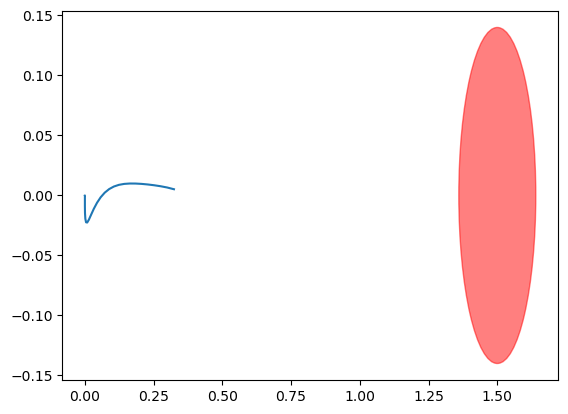

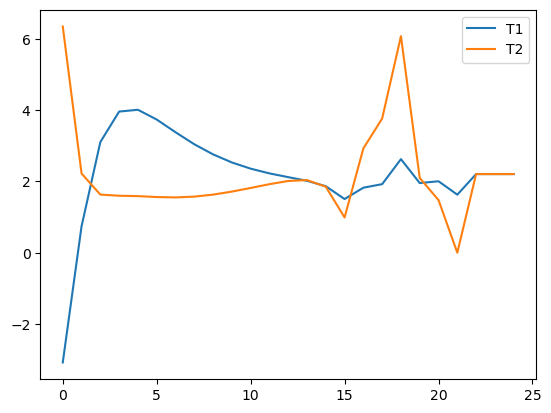

In [254]:
# Choose initial guess and compute cost and residual
z = np.zeros((N+1) * x_dim + N * u_dim)
#X_ref = reference_trajectory()
#z[:(N+1)*x_dim] = X_ref.flatten()
z[(N+1)*x_dim:] = np.tile(u_ref, N)

lam = np.zeros((N+1) * x_dim)
nu = np.zeros(N)

obstacle_center = [1.5, 0.0]

res = [
    np.linalg.norm(grad_L(z, lam, nu, obstacle_center), np.inf),
    np.linalg.norm(g(z), np.inf),
    np.linalg.norm(np.maximum(0, h(z, obstacle_center)), np.inf),
]
cost = J(z)

# Create list of pairs for filter method
pairs = [[J(z), np.linalg.norm(g(z), np.inf), np.linalg.norm(np.maximum(0, h(z, obstacle_center)), np.inf)]]

# Choose parameters
max_iters = 500
max_inner_iters = 50
tol = 1e-8
rho = 0.5
delta = 1e-6
omega = 10.0

# Iterate
alpha = None
H = None
mu = None
success = False
for i in range(max_iters):
    # Show progress
    mu_str = f' ; mu = {mu:.2e}' if mu is not None else ''
    alpha_str = f' ; alpha = {alpha:.2e}' if alpha is not None else ''
    print(f'{i:3d} : |L_x| = {res[0]:11.8f}; |g| = {res[1]:11.8f}; |h| = {res[2]:11.8f}; J = {cost:7.4f}' + mu_str + alpha_str)

    # Check stopping condition (residuals)
    if (res[0] < tol) and (res[1] < tol) and (res[2] < tol):
        success = True
        if i == 0:
            print(f'success (initial guess satisfies necessary conditions for optimality)')
        else:
            print(f'success (converged at iteration {i})')
        break
    
    # Choose descent direction (Newton step with regularization)
    Hessian_L_val = Hessian_L(z, lam, nu, obstacle_center)
    H = Hessian_L_val.copy()
    grad_J_val = grad_J(z)
    Jacobian_g_val = Jacobian_g(z)
    g_val = g(z)
    Jacobian_h_val = Jacobian_h(z, obstacle_center)
    h_val = h(z, obstacle_center)
    mu_iters = 0
    while True:
        try:
            # Add regularization to the Hessian
            if mu_iters == 0:
                mu = 0.0
            else:
                mu = delta * (omega**mu_iters)
            H = Hessian_L_val + (mu * np.eye(len(z)))
            # Attempt a Cholesky factorization - if it fails, then H is not
            # positive definite and we need to add more regularization
            L_chol = np.linalg.cholesky(H)
            # Attempt to solve for the descent direction - if it fails, then
            # H is ill-conditioned and we need to add more regularization

            problem = Problem(P=H, q=grad_J_val, A=Jacobian_g_val, b=-g_val, G=Jacobian_h_val, h=-h_val)
            solution = solve_problem(problem, solver='proxqp', eps_abs=1e-8, eps_rel=1e-8)
            step_z = solution.x
            step_lam = solution.y - lam
            step_nu = solution.z - nu
            #
            # ^^^ Be careful to distinguish between solution.y (dual variable
            #     associated with equality constraints) and solution.z (dual
            #     variable associated with inequality constraints). Get this
            #     wrong and you will have trouble finding your mistake!
            #
            break
        except np.linalg.LinAlgError:
            mu_iters += 1
    
    # Apply backtracking line search (filter method)
    alpha = 1.0
    no_progress = True
    for i_inner in range(max_inner_iters):
        if is_dominated([J(z + alpha * step_z),
                         np.linalg.norm(g(z + alpha * step_z), np.inf),
                         np.linalg.norm(np.maximum(0, h(z + alpha * step_z, obstacle_center)), np.inf)], 
                        pairs, verbose=True):
            alpha *= rho
        else:
            no_progress = False
            break
    
    # Check stopping condition (no progress)
    if no_progress:
        print(f'failure (no progress at iteration {i})')
        break

    # Update guess
    z = z + alpha * step_z
    lam = lam + alpha * step_lam
    nu = nu + alpha * step_nu
    res = [
        np.linalg.norm(grad_L(z, lam, nu, obstacle_center), np.inf),
        np.linalg.norm(g(z), np.inf),
        np.linalg.norm(np.maximum(0, h(z, obstacle_center)), np.inf),
    ]
    cost = J(z)
    pairs.append([J(z), np.linalg.norm(g(z), np.inf), np.linalg.norm(np.maximum(0, h(z, obstacle_center)), np.inf)])

# Check if max iters was exceeded
if (not success) and (i == max_iters):
    print(f'failure (exceeded maximum number {max_iters} of iterations)')

plt.figure()
plt.plot(z[:(N+1)*x_dim].reshape(N+1, x_dim)[:, 0], z[:(N+1)*x_dim].reshape(N+1, x_dim)[:, 1], label='optimized trajectory')
#plt.plot(X_ref[:, 0], X_ref[:, 1], label='reference trajectory', linestyle='dashed')
circle = plt.Circle(obstacle_center, r, color='red', alpha=0.5)
plt.gca().add_patch(circle)

plt.figure()
plt.plot(z[(N+1)*x_dim:].reshape(N, u_dim)[:, 0], label='T1')
plt.plot(z[(N+1)*x_dim:].reshape(N, u_dim)[:, 1], label='T2')
plt.legend()
plt.show()